# Duomenu aibes aprasymas, transformacijos

#### Importuojame paketus, paruošiame grafikų stilių

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt
import contextily as cx

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

## Duomenų importavimas

Visi failai pasiekiami OneDrive.

*Tolimesnio kodo paleidimas reikalauja daug RAM. Leisti kodą po "1 laboratorinio darbo kopija". Failas data.csv įkeltas į OneDrive.*

In [2]:
rng = np.random.default_rng(1)

In [3]:
SHIP_TYPE = ['Cargo', 'Tanker', 'Passenger', 'Pilot', 'Fishing']

def filter_data_set(df):
    df_filtered = df[
        df['Latitude'].between(54, 56) &
        df['Longitude'].between(12, 17) &
        (df['Navigational status'] == 'Under way using engine') &
        (df['Type of mobile'] == 'Class A') &
        df['Ship type'].isin( SHIP_TYPE )
    ].copy(deep=True)

    return df_filtered

In [4]:
df_parts = []
file_names = [
    'aisdk-2026-02-01.csv',
    'aisdk-2026-02-02.csv',
    'aisdk-2026-02-03.csv',
    'aisdk-2026-02-04.csv',
    'aisdk-2026-02-05.csv',
]

for file_name in file_names:

    df_chunks = pd.read_csv(file_name, chunksize=2**20)

    for df_chunk in df_chunks:
        df_filtered = filter_data_set(df_chunk)
        df_parts.append(df_filtered)
        del df_chunk

    del df_chunks

In [5]:
df = pd.concat(df_parts, axis=0)

In [6]:
df.groupby('Ship type')['MMSI'].nunique()

Ship type
Cargo        479
Fishing       18
Passenger     46
Pilot         13
Tanker       175
Name: MMSI, dtype: int64

In [7]:
dfs = []

for ship_type in df['Ship type'].unique():
    type_mask = df['Ship type'] == ship_type
    type_mmsi = rng.choice(
        df[type_mask]['MMSI'].unique(),
        size=13,
        replace=False
    )

    dfs.append( df[df['MMSI'].isin(type_mmsi)].copy() )

In [8]:
df = pd.concat(dfs, axis=0)
df.to_csv('data.csv')

## Leisti nuo čia

In [9]:
df = pd.read_csv('data.csv', engine='pyarrow')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338676 entries, 0 to 1338675
Data columns (total 27 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0                                   1338676 non-null  int64  
 1   # Timestamp                     1338676 non-null  object 
 2   Type of mobile                  1338676 non-null  object 
 3   MMSI                            1338676 non-null  int64  
 4   Latitude                        1338676 non-null  float64
 5   Longitude                       1338676 non-null  float64
 6   Navigational status             1338676 non-null  object 
 7   ROT                             901702 non-null   float64
 8   SOG                             1338637 non-null  float64
 9   COG                             1338635 non-null  float64
 10  Heading                         1215303 non-null  float64
 11  IMO                             1338676 non-null  object 
 12  

# 1 laboratorinio darbo kopija

In [10]:
df['Ship type'].value_counts()

Ship type
Pilot        532179
Passenger    361389
Fishing      165602
Cargo        153774
Tanker       125732
Name: count, dtype: int64

### Ištiriam praleistas reikšmes, skirtumus tarp stebėjimų

Čia mūsų siekis bus dvejopas:
1. Susitvarkyti su praleistomis reikšmėmis;
2. Išplėsti laiko eilutes į lygiai vienos minutės intervalus, t. y, padaryti taip, kad tarp vieno laivo AIS signalų visą laiką būtų vienos minutės skirtumas.

In [11]:
numerical = ['ROT', 'SOG', 'COG', 'Heading']
df[numerical].isnull().sum()

ROT        436974
SOG            39
COG            41
Heading    123373
dtype: int64

In [12]:
df_filtered = df

In [13]:
df_filtered[numerical].isnull().agg(['sum', 'mean'])

,ROT,SOG,COG,Heading
sum,436974.000000,39.000000,41.000000,123373.00000
mean,0.326423,0.000029,0.000031,0.09216


#### Praleistų reikšmių skaičius/dalis kiekvienam kintamajam

In [14]:
output = []

for ship_type, type_data in df_filtered.groupby('Ship type'):

    for col in numerical:
        output.append({
            'Laivo tipas': ship_type,
            'Kintamasis': col,
            'Praleistų reikšmių dalis, %': type_data[col].isnull().mean() * 100
        })

pd.DataFrame(output).pivot(columns=['Kintamasis'], index=['Laivo tipas'])

Praleistų reikšmių dalis, %                                
Kintamasis                          COG    Heading        ROT       SOG
Laivo tipas                                                            
Cargo                          0.001301   0.000000  35.405205  0.000000
Fishing                        0.002415   3.311554  29.165107  0.002415
Passenger                      0.000000  16.747051  21.173306  0.000000
Pilot                          0.006577  10.511313  46.002191  0.006577
Tanker                         0.000000   1.135749  10.259918  0.000000

> Passenger turi 23 % praleistų reikšmių ROT. ROT - dažniausiai nulis, taigi jam taikysime 0 įrašymą

In [15]:
for mmsi, mmsi_data in df_filtered.groupby('MMSI'):

    if any( df_filtered[numerical].isnull().mean() >= 1 ):
        print(mmsi)

> Užpildome

In [16]:
df.loc[ df['ROT'].isnull(), 'ROT' ] = 0

> Toliau reikia ištirti ar laiko skirtumas tarp stebėjimų neviršija 2 valandų (literatūroje taikyta riba)

In [17]:
from datetime import timedelta

In [18]:
df_filtered['# Timestamp'] = pd.to_datetime( df_filtered['# Timestamp'], dayfirst=True )
df_filtered['day'] = df_filtered['# Timestamp'].dt.normalize()

In [19]:
df = []
for mmsi, mmsi_data in df_filtered.groupby(['MMSI', 'day']):

    mmsi_data = mmsi_data\
        .sort_values('# Timestamp')\
        .reset_index(drop=True)

    time_diff = mmsi_data['# Timestamp'].diff(1)
    max_time_diff = time_diff.max()

    if max_time_diff >= timedelta(hours=2):
        first_gap = mmsi_data[ time_diff >= timedelta(hours=2) ].index[0]
        mmsi_data_wo_gap = mmsi_data.iloc[:first_gap, :]
        df.append(mmsi_data_wo_gap)

    else:
        df.append(mmsi_data)

In [20]:
df_filtered = pd.concat(df).reset_index(drop=True)

## isskirtys

In [21]:

numerical_cols = ["ROT", "SOG", "COG", "Heading"]
for col in numerical_cols:
    df_col = df_filtered[col]
    
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_filtered[(df_filtered[col] < lower) | (df_filtered[col] > upper)]
    
    print(f"\n{col}")
    print("Lower:", round(lower, 2))
    print("Upper:", round(upper, 2))
    print("Min:", round(df_col.min(), 2))
    print("Max:", round(df_col.max(), 2))
    print("Outliers:", len(outliers))



ROT
Lower: 0.0
Upper: 0.0
Min: -420.0
Max: 708.7
Outliers: 129340

SOG
Lower: -17.85
Upper: 29.75
Min: 0.0
Max: 74.5
Outliers: 4

COG
Lower: -201.95
Upper: 553.65
Min: 0.0
Max: 359.9
Outliers: 0

Heading
Lower: -226.0
Upper: 590.0
Min: 0.0
Max: 359.0
Outliers: 0


In [22]:
numerical_cols = ["ROT", "SOG"]

for ship_type, group in df_filtered.groupby("Ship type"):
    
    print(f"\n===== Ship type: {ship_type} =====")
    
    for col in numerical_cols:
        df_col = group[col].dropna()
        
        Q1 = df_col.quantile(0.25)
        Q3 = df_col.quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = group[(group[col] < lower) | (group[col] > upper)]
        
        print(f"\n{col}")
        print("Q1:", round(Q1, 2))
        print("Q3:", round(Q3, 2))
        print("Lower:", round(lower, 2))
        print("Upper:", round(upper, 2))
        print("Min:", round(df_col.min(), 2))
        print("Max:", round(df_col.max(), 2))
        print("Outliers:", len(outliers))



===== Ship type: Cargo =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -40.2
Max: 45.7
Outliers: 19576

SOG
Q1: 7.6
Q3: 10.9
Lower: 2.65
Upper: 15.85
Min: 0.0
Max: 14.6
Outliers: 1260

===== Ship type: Fishing =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: 0.0
Max: 0.0
Outliers: 0

SOG
Q1: 0.0
Q3: 11.5
Lower: -17.25
Upper: 28.75
Min: 0.0
Max: 74.5
Outliers: 4

===== Ship type: Passenger =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -82.5
Max: 140.0
Outliers: 53399

SOG
Q1: 0.0
Q3: 16.4
Lower: -24.6
Upper: 41.0
Min: 0.0
Max: 22.8
Outliers: 0

===== Ship type: Pilot =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -420.0
Max: 708.7
Outliers: 1460

SOG
Q1: 0.0
Q3: 6.9
Lower: -10.35
Upper: 17.25
Min: 0.0
Max: 29.0
Outliers: 37167

===== Ship type: Tanker =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -54.7
Max: 82.5
Outliers: 54905

SOG
Q1: 9.2
Q3: 12.1
Lower: 4.85
Upper: 16.45
Min: 0.0
Max: 15.3
Outliers: 1452


Taikant IQR metodą nustatyta, kad kintamasis ROT turi labai daug išskirčių. Tačiau tai paaiškinama tuo, kad didžioji dalis stebėjimų turi reikšmę 0 (laivas juda tiesiai), todėl kvartilių intervalas lygus nuliui ir visi nenuliniai stebėjimai klasifikuojami kaip išskirtys. Todėl pasirinkome išskirčių nešalinti.


# isimt ROT = 0 ir su boxplotu patikrint isskirtis

In [23]:
df_isskirciu = df_filtered.copy()
df_isskirciu = df_isskirciu[df_isskirciu["ROT"] != 0]

In [24]:

numerical_cols = ["ROT", "SOG", "COG", "Heading"]
for col in numerical_cols:
    df_col = df_isskirciu[col]
    
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_isskirciu[(df_isskirciu[col] < lower) | (df_isskirciu[col] > upper)]
    
    print(f"\n{col}")
    print("Lower:", round(lower, 2))
    print("Upper:", round(upper, 2))
    print("Min:", round(df_col.min(), 2))
    print("Max:", round(df_col.max(), 2))
    print("Outliers:", len(outliers))



ROT
Lower: -11.6
Upper: 11.6
Min: -420.0
Max: 708.7
Outliers: 9970

SOG
Lower: 1.5
Upper: 23.9
Min: 0.0
Max: 23.1
Outliers: 633

COG
Lower: -213.65
Upper: 506.75
Min: 0.0
Max: 359.9
Outliers: 0

Heading
Lower: -198.5
Upper: 493.5
Min: 0.0
Max: 359.0
Outliers: 0


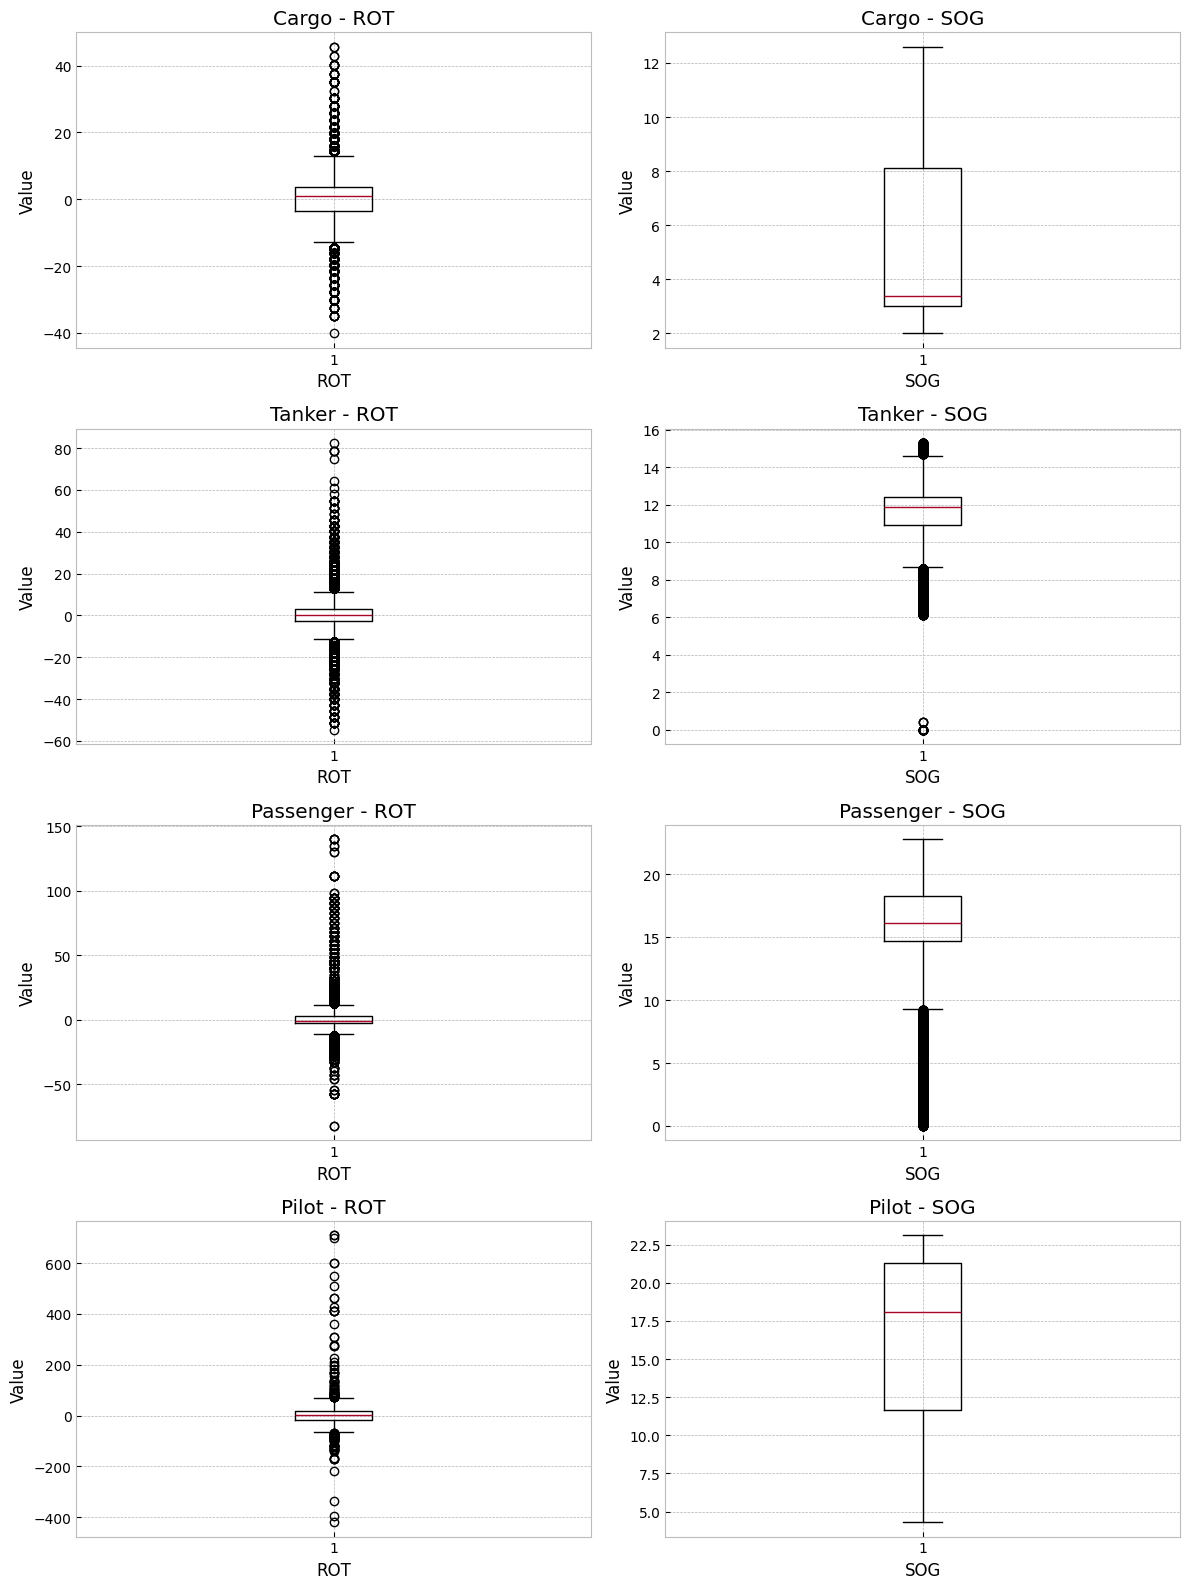

In [25]:
import matplotlib.pyplot as plt
import math

numerical_cols = ["ROT", "SOG"]

ship_types = df_isskirciu["Ship type"].dropna().unique()
n_ship_types = len(ship_types)
n_cols = len(numerical_cols)

# Grid dimensijos
rows = n_ship_types
cols = n_cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))

# Jei tik vienas ship type arba vienas column – sutvarkome indexing
if rows == 1:
    axes = [axes]
if cols == 1:
    axes = [[ax] for ax in axes]

for i, ship_type in enumerate(ship_types):
    group = df_isskirciu[df_isskirciu["Ship type"] == ship_type]
    
    for j, col in enumerate(numerical_cols):
        ax = axes[i][j]
        
        ax.boxplot(group[col].dropna())
        ax.set_title(f"{ship_type} - {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


### Praleistų reikšmių užpildymas: kubinė interpoliacija

In [26]:
dfs = []
tarpai = []
praleistu_count = 0

for mmsi, mmsi_df in df_filtered.groupby('MMSI'):

    tarpai.extend( mmsi_df['# Timestamp'].diff(1).dropna().to_list() )
    
    # Atliekam transformacijq
    mmsi_df['Heading'] = mmsi_df['Heading']\
        .apply(lambda x: 360 - x if x > 180.0 else x)
    mmsi_df['COG'] = mmsi_df['COG']\
        .apply(lambda x: 360 - x if x > 180.0 else x)

    # Išplėčiame ir interpoliuojame
    output_df = mmsi_df.set_index('# Timestamp')\
        [['Latitude', 'Longitude', 'ROT', 'SOG', 'COG', 'Heading']]\
        .resample('60s')\
        .median()

    if output_df.shape[0] <= 2:
        continue

    praleistu_count += output_df.isnull().sum()
    
    output_df = output_df\
        .interpolate('pchip')\
        .reset_index()

    # Ištaisome klaidas
    output_df['Heading'] = np.clip(output_df['Heading'], 0, 360)
    output_df['COG'] = np.clip(output_df['COG'], 0, 360)
    output_df['Latitude'] = np.clip(output_df['Latitude'], 54.0, 56.0)
    output_df['Longitude'] = np.clip(output_df['Longitude'], 12.0, 17.0)

    # Apskaičiuojame komponentes
    output_df['delta_lat'] = output_df['Latitude'].diff(1).abs()
    output_df['delta_lon'] = output_df['Longitude'].diff(1).abs()

    # Priskiriame MMSI ir laivo tipo reikšmes, nes šiuo metu jų nėra output_df
    output_df['MMSI'] = mmsi
    output_df['Ship type'] = mmsi_df['Ship type'].values[0]

    # Surenkame
    dfs.append(output_df)

data = pd.concat(dfs, ignore_index=True).dropna()

In [27]:
tarpai = np.array(tarpai)
tarpai = tarpai[ tarpai != 0 ]

np.quantile(tarpai, [0.05, 0.95])

array([Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:19')],
      dtype=object)

> Tarpai tarp AIS stebėjimų yra 0 - 20 sekundžių

In [28]:
praleistu_count / data.shape[0]

Latitude     0.427832
Longitude    0.427832
ROT          0.427832
SOG          0.427832
COG          0.427832
Heading      0.530916
dtype: float64

> Interpoliuota: 5-7 % praleistų reikšmių

In [29]:
print('Stebėjimų skaičius', data.shape[0])
print('Laivų skaičius', data['MMSI'].nunique())

Stebėjimų skaičius 184694
Laivų skaičius 60


## Rinkinio peržiūra

In [30]:
data = data.sort_values(['MMSI', '# Timestamp'])

In [31]:
data.head()

,# Timestamp,Latitude,Longitude,ROT,SOG,COG,Heading,delta_lat,delta_lon,MMSI,Ship type
1,2026-02-01 00:35:00,54.354806,12.007195,0.0,16.5,63.80,65.0,0.001397,0.004859,209764000,Passenger
2,2026-02-01 00:36:00,54.356933,12.014483,0.0,16.4,63.10,65.0,0.002127,0.007288,209764000,Passenger
3,2026-02-01 00:37:00,54.359192,12.022292,0.0,16.4,63.60,65.0,0.002259,0.007809,209764000,Passenger
4,2026-02-01 00:38:00,54.360967,12.028477,0.0,16.4,63.75,65.0,0.001775,0.006185,209764000,Passenger
5,2026-02-01 00:39:00,54.363217,12.036310,0.0,16.4,63.80,65.0,0.002250,0.007833,209764000,Passenger


In [32]:

import pandas as pd

numeric_cols = data[numerical]

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
min_vals = numeric_cols.min()
max_vals = numeric_cols.max()

desc_stats = pd.DataFrame({
    'Minimumas': min_vals,
    '$Q_1$': Q1,
    'Vidurkis': numeric_cols.mean(),
    '$Q_3$': Q3,
    '$IQR$': Q3 - Q1,
    'Maksimumas': max_vals,
    'Standartinis nuokrypis': numeric_cols.std()
})

pd.options.display.float_format = '{:.3f}'.format
print(desc_stats.to_latex(float_format='{:.3f}'.format))


\begin{tabular}{lrrrrrrr}
\toprule
 & Minimumas & $Q_1$ & Vidurkis & $Q_3$ & $IQR$ & Maksimumas & Standartinis nuokrypis \\
\midrule
ROT & -115.200 & 0.000 & 0.227 & 0.000 & 0.000 & 171.600 & 2.879 \\
SOG & 0.000 & 0.000 & 8.148 & 13.300 & 13.300 & 28.800 & 6.745 \\
COG & 0.000 & 44.500 & 90.126 & 131.209 & 86.709 & 180.000 & 51.904 \\
Heading & 0.000 & 45.846 & 85.446 & 125.000 & 79.154 & 180.000 & 48.375 \\
\bottomrule
\end{tabular}



In [33]:
data['ROT'] = np.arcsinh(data['ROT'])

# kampų transformacija
heading_rad = np.deg2rad(data['Heading'])
cog_rad = np.deg2rad(data['COG'])

data['Heading_sin'] = np.sin(heading_rad)
data['Heading_cos'] = np.cos(heading_rad)

data['COG_sin'] = np.sin(cog_rad)
data['COG_cos'] = np.cos(cog_rad)

# pašaliname originalius kampus
# data = data.drop(columns=['Heading', 'COG'])

In [34]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
standscaler = StandardScaler()
minmaxscaler = MinMaxScaler()
numerical = [
    'Latitude',
    'Longitude',
    'ROT',
    'SOG',
    'Heading_sin',
    'Heading_cos',
    'COG_sin',
    'COG_cos',
    'delta_lon',
    'delta_lat'
]
standscaler.fit(data[numerical])
minmaxscaler.fit(data[numerical])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [35]:
standdata = data.copy()
standdata[numerical] = standscaler.transform(data[numerical])

In [36]:
standdata[numerical].describe()

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
count,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.324,-1.227,-7.452,-1.208,-2.190,-1.608,-1.989,-1.428,-0.562,-0.573
25%,-0.759,-0.683,-0.071,-1.208,-0.821,-0.961,-0.971,-0.939,-0.560,-0.570
50%,0.199,-0.424,-0.071,0.186,0.289,0.121,0.285,0.003,-0.549,-0.553
75%,0.678,0.672,-0.071,0.764,0.896,0.967,0.952,1.024,0.104,0.183
max,1.446,2.225,7.850,3.062,1.020,1.428,1.123,1.434,17.958,8.500


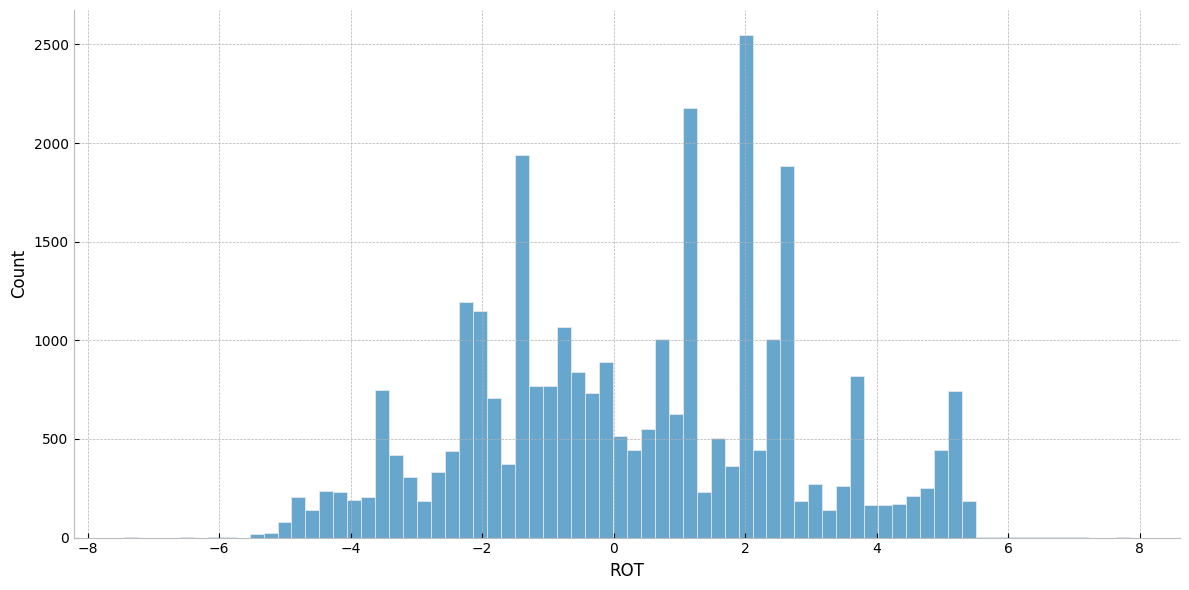

In [37]:
sns.displot(standdata[standdata.ROT != standdata.ROT.median()]['ROT'], height=6, aspect=2)

<Axes: ylabel='ROT'>

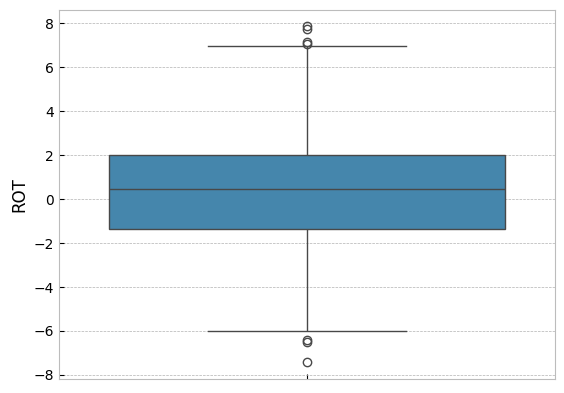

In [38]:
sns.boxplot(standdata[standdata.ROT != standdata.ROT.median()]['ROT'])

In [39]:
data[numerical] = minmaxscaler.transform(data[numerical])

In [40]:
data[numerical].describe()

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
count,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000,184694.000
mean,0.616,0.355,0.487,0.283,0.682,0.530,0.639,0.499,0.030,0.063
std,0.265,0.290,0.065,0.234,0.312,0.329,0.321,0.349,0.054,0.110
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.415,0.157,0.482,0.000,0.426,0.213,0.327,0.171,0.000,0.000
50%,0.669,0.232,0.482,0.326,0.772,0.570,0.731,0.500,0.001,0.002
75%,0.796,0.550,0.482,0.462,0.961,0.848,0.945,0.857,0.036,0.083
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Koreliacijos

In [41]:
corr = data[numerical]\
    .select_dtypes(include=['float64'])\
    .corr(method='spearman')

In [42]:
corr

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
Latitude,1.000,0.061,0.037,-0.237,-0.092,-0.004,-0.117,-0.033,-0.133,-0.374
Longitude,0.061,1.000,0.076,-0.151,0.268,0.127,0.184,0.086,0.200,0.045
ROT,0.037,0.076,1.000,0.001,-0.005,-0.003,-0.019,-0.013,-0.034,-0.042
SOG,-0.237,-0.151,0.001,1.000,0.140,-0.229,0.243,-0.040,0.368,0.392
Heading_sin,-0.092,0.268,-0.005,0.140,1.000,-0.129,0.630,0.002,0.066,-0.100
Heading_cos,-0.004,0.127,-0.003,-0.229,-0.129,1.000,-0.072,0.724,-0.122,-0.123
COG_sin,-0.117,0.184,-0.019,0.243,0.630,-0.072,1.000,0.001,0.129,-0.033
COG_cos,-0.033,0.086,-0.013,-0.040,0.002,0.724,0.001,1.000,-0.038,-0.067
delta_lon,-0.133,0.200,-0.034,0.368,0.066,-0.122,0.129,-0.038,1.000,0.727
delta_lat,-0.374,0.045,-0.042,0.392,-0.100,-0.123,-0.033,-0.067,0.727,1.000


# paziureti koreliacijas pagal laivu tipus

## Aprasomoji statistika, palyginimoji analizė

### Aprasomoji statistika

In [43]:
import pandas as pd

numeric_cols = data[numerical]

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
min_vals = numeric_cols.min()
max_vals = numeric_cols.max()

desc_stats = pd.DataFrame({
    'min': min_vals,
    'Q1': Q1,
    'median': numeric_cols.median(),
    'mean': numeric_cols.mean(),
    'Q3': Q3,
    'IQR': Q3 - Q1,
    'max': max_vals,
    'range': max_vals - min_vals,
    'variance': numeric_cols.var(),
    'std_dev': numeric_cols.std()
})

pd.options.display.float_format = '{:.3f}'.format
print(desc_stats)


              min    Q1  median  mean    Q3   IQR   max  range  variance  \
Latitude    0.000 0.415   0.669 0.616 0.796 0.381 1.000  1.000     0.070   
Longitude   0.000 0.157   0.232 0.355 0.550 0.393 1.000  1.000     0.084   
ROT         0.000 0.482   0.482 0.487 0.482 0.000 1.000  1.000     0.004   
SOG         0.000 0.000   0.326 0.283 0.462 0.462 1.000  1.000     0.055   
Heading_sin 0.000 0.426   0.772 0.682 0.961 0.535 1.000  1.000     0.097   
Heading_cos 0.000 0.213   0.570 0.530 0.848 0.635 1.000  1.000     0.109   
COG_sin     0.000 0.327   0.731 0.639 0.945 0.618 1.000  1.000     0.103   
COG_cos     0.000 0.171   0.500 0.499 0.857 0.686 1.000  1.000     0.122   
delta_lon   0.000 0.000   0.001 0.030 0.036 0.036 1.000  1.000     0.003   
delta_lat   0.000 0.000   0.002 0.063 0.083 0.083 1.000  1.000     0.012   

             std_dev  
Latitude       0.265  
Longitude      0.290  
ROT            0.065  
SOG            0.234  
Heading_sin    0.312  
Heading_cos    0.329  
CO

### Palyginamoji analizė

/tmp/ipykernel_10234/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


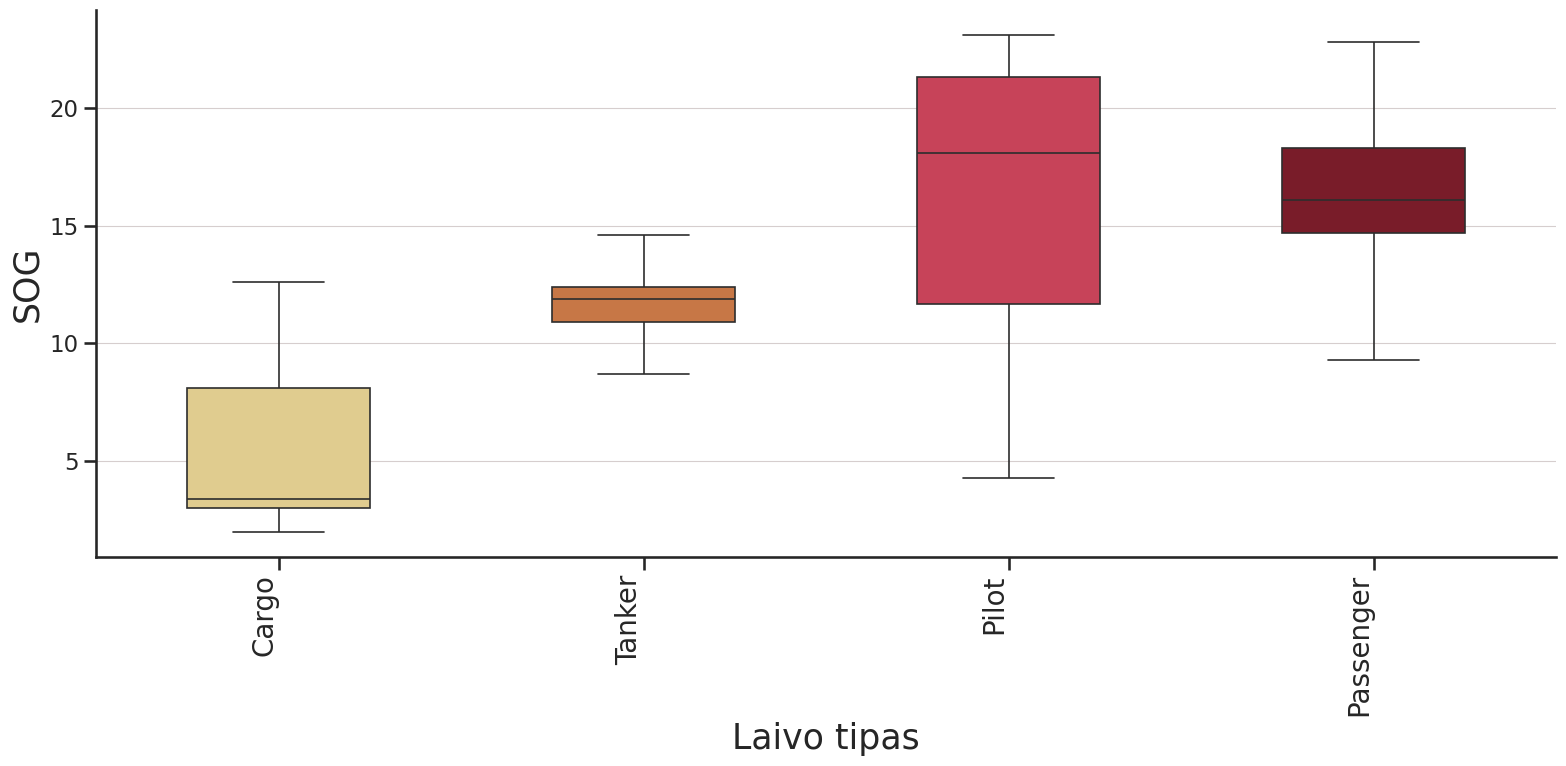

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_isskirciu = df_filtered[ df_filtered['ROT'] != 0 ]

def plot_box_by_shiptype(df, variables):
    
    dfp = df.dropna(subset=["Ship type"]).copy()
    dfp["Ship type"] = dfp["Ship type"].astype(str).str.strip()
    
    variables = [
        col for col in variables 
        if col in dfp.columns and pd.api.types.is_numeric_dtype(dfp[col])
    ]
    
    sns.set_theme(style="ticks", context="talk")

    ship_order = [
        "Cargo",
        "Tanker",
        "Pilot",
        "Passenger",
        "Fishing"
    ]

    color_map = {
        "Cargo": "#EDD382",
        "Tanker": "#DD7230",
        "Pilot": "#DD2D4A",
        "Passenger": "#880D1E",
        "Fishing": "#E56399",
    }  

    ship_order = [s for s in ship_order if s in dfp["Ship type"].unique()]

    for var in variables:
        
        plt.figure(figsize=(16, 8))
        
        valid_ship_types = [
            s for s in ship_order
            if s in dfp["Ship type"].unique()
            and dfp.loc[dfp["Ship type"] == s, var].notna().any()
        ]
        
        sns.boxplot(
        data=dfp,
        x="Ship type",
        y=var,
        order=valid_ship_types,
        palette=color_map,
        width=0.5,
        linewidth=1.2,
        showfliers=False
    )

        ax = plt.gca()
        ax.yaxis.grid(True, which='major', color="#D6CECEE7", linewidth=0.8)
        ax.xaxis.grid(False)

        plt.xticks(rotation=90, ha="right", fontsize=20)
        # plt.title(f"{var} pasiskirstymas pagal laivo tipą", fontsize=25, weight="bold")
        plt.xlabel("Laivo tipas", fontsize=25)
        plt.ylabel(var, fontsize=25)

        sns.despine()
        plt.tight_layout()
        plt.show()


plot_box_by_shiptype(df_isskirciu, ['SOG'])

/tmp/ipykernel_10234/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


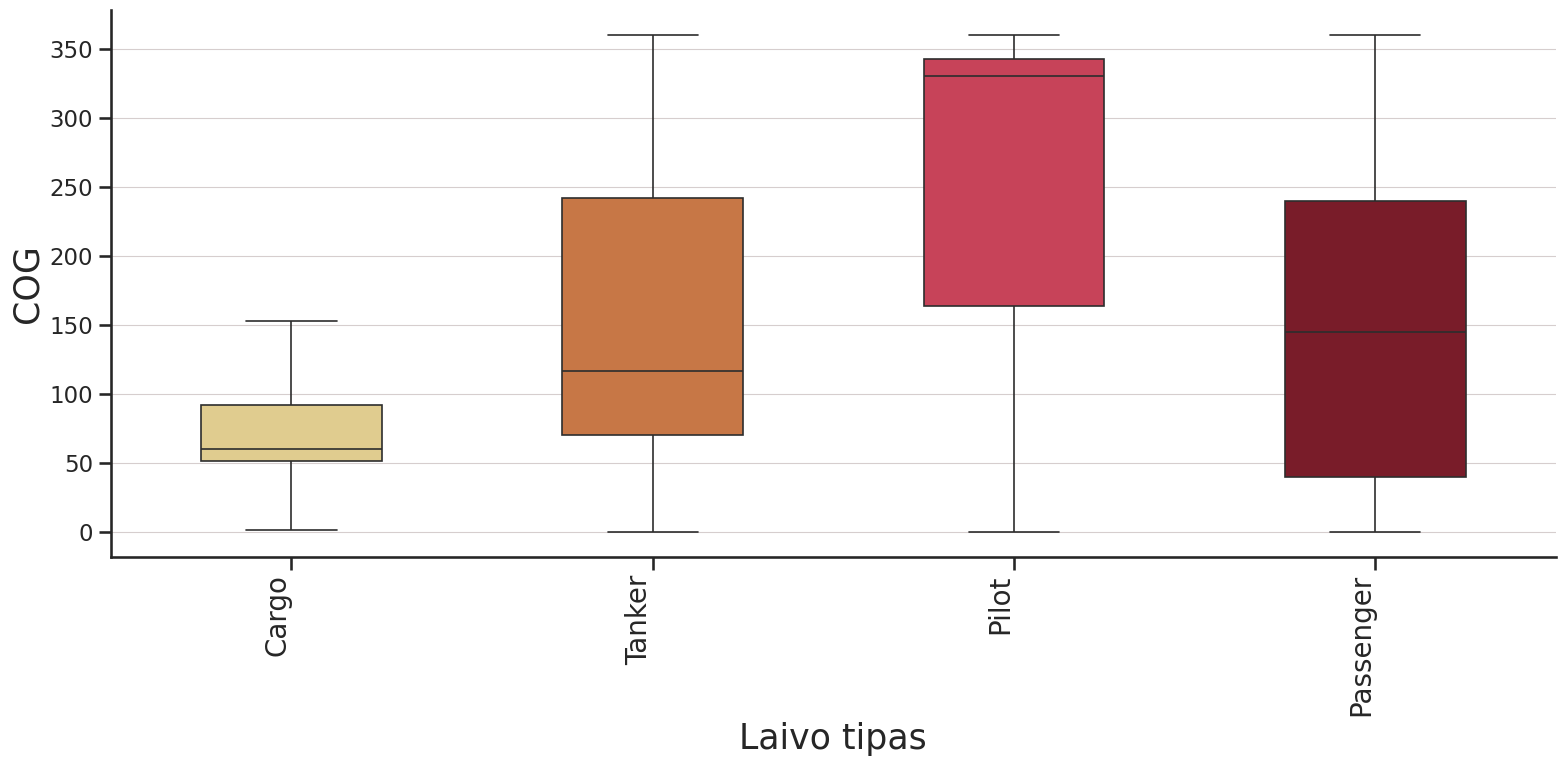

In [45]:
plot_box_by_shiptype(df_isskirciu, ['COG'])

/tmp/ipykernel_10234/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


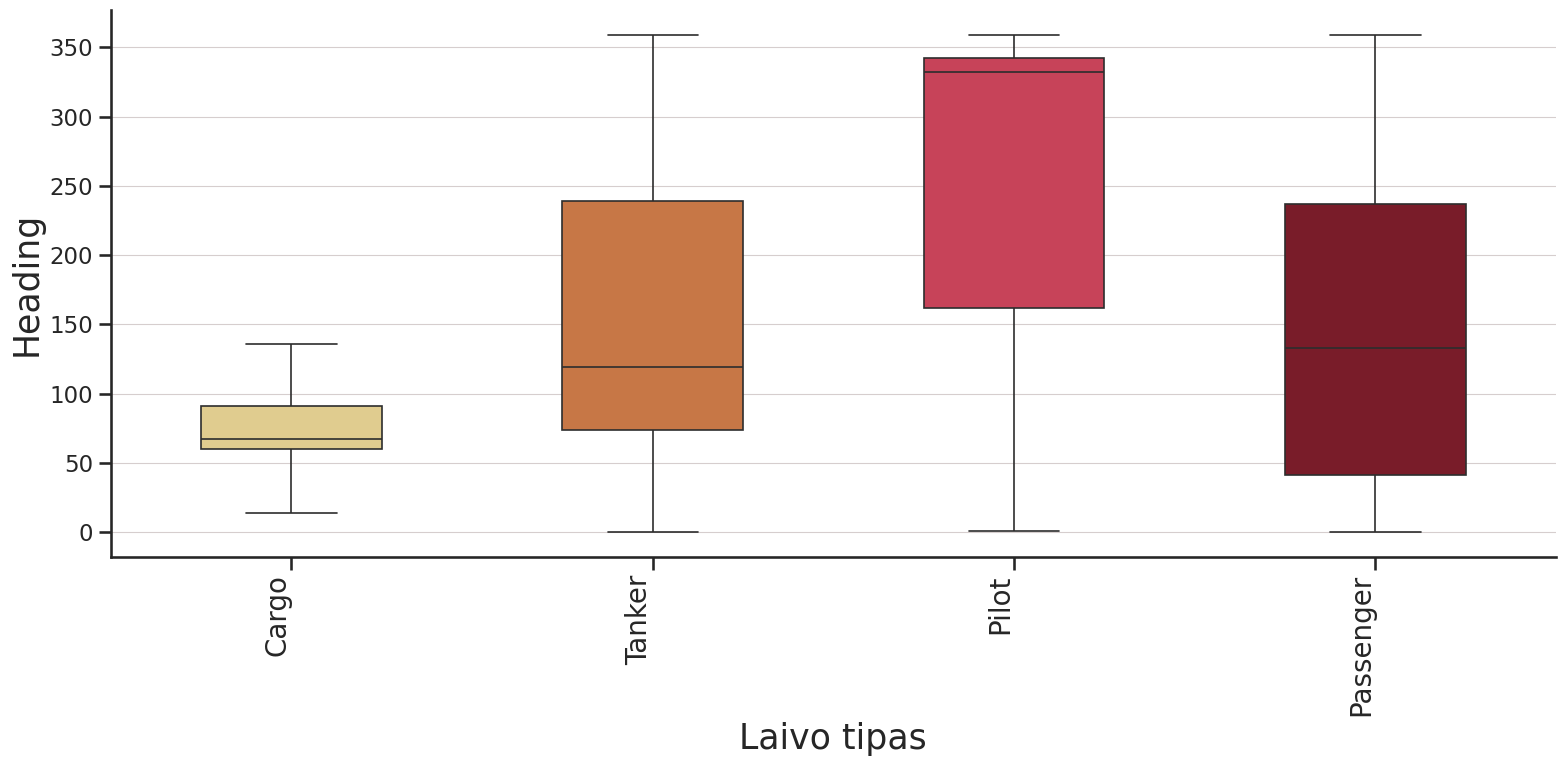

In [46]:
plot_box_by_shiptype(df_isskirciu, ['Heading'])

/tmp/ipykernel_10234/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


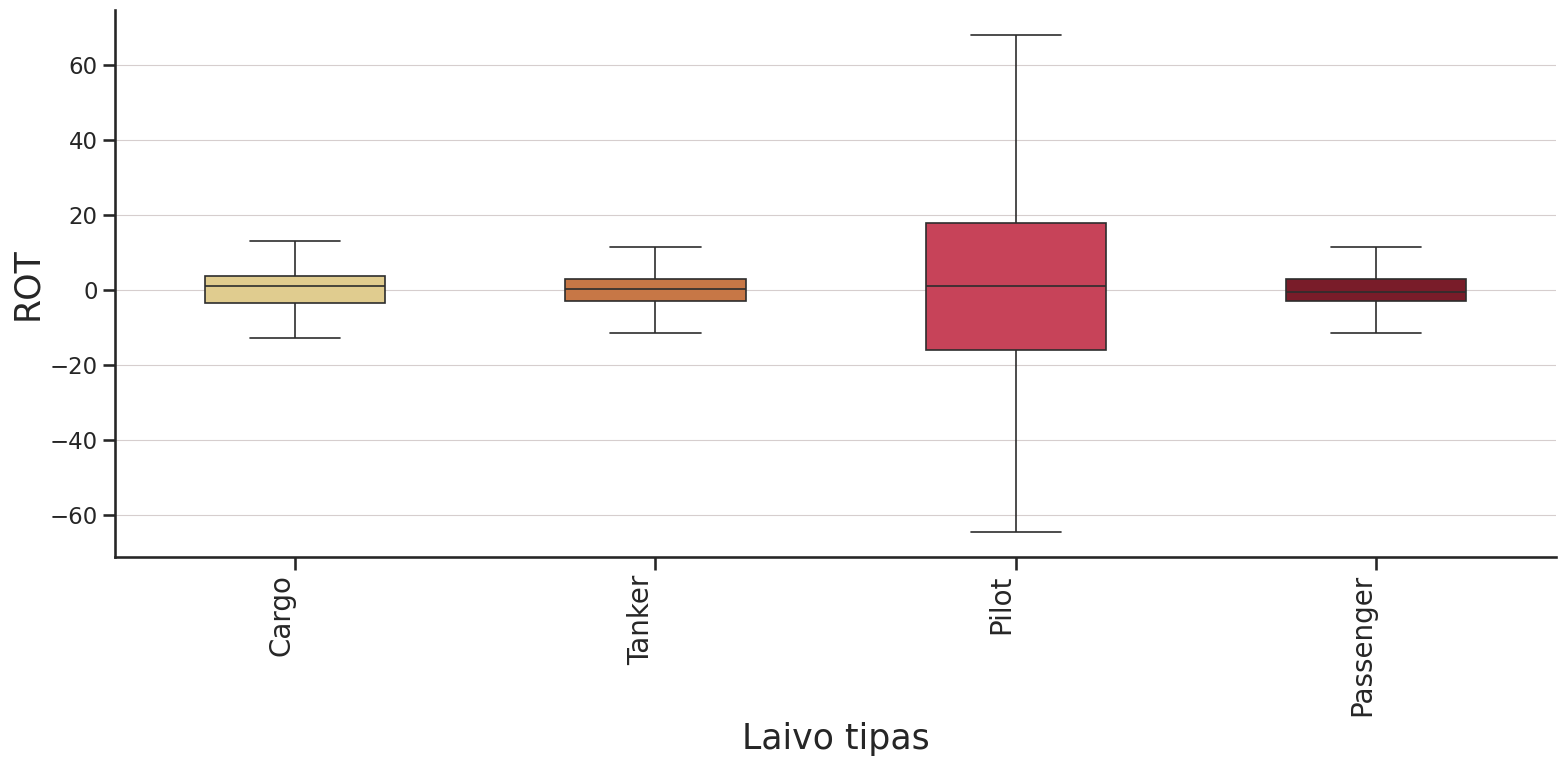

In [47]:
plot_box_by_shiptype(df_isskirciu, ['ROT'])

In [48]:
print( data[numerical].describe().drop(['count', 'mean', 'std']).T.to_latex() )

\begin{tabular}{lrrrrr}
\toprule
 & min & 25% & 50% & 75% & max \\
\midrule
Latitude & 0.000000 & 0.415190 & 0.669119 & 0.796323 & 1.000000 \\
Longitude & 0.000000 & 0.157434 & 0.232471 & 0.549989 & 1.000000 \\
ROT & 0.000000 & 0.482334 & 0.482334 & 0.482334 & 1.000000 \\
SOG & 0.000000 & 0.000000 & 0.326389 & 0.461806 & 1.000000 \\
Heading_sin & 0.000000 & 0.426217 & 0.772250 & 0.961262 & 1.000000 \\
Heading_cos & 0.000000 & 0.213212 & 0.569587 & 0.848298 & 1.000000 \\
COG_sin & 0.000000 & 0.327145 & 0.730855 & 0.944878 & 1.000000 \\
COG_cos & 0.000000 & 0.170596 & 0.500000 & 0.856625 & 1.000000 \\
delta_lon & 0.000000 & 0.000105 & 0.000714 & 0.035986 & 1.000000 \\
delta_lat & 0.000000 & 0.000243 & 0.002205 & 0.083232 & 1.000000 \\
\bottomrule
\end{tabular}



## Sekų formavimas

In [49]:
trajectories=[]
labels=[]

for mmsi, mmsi_data in data.groupby('MMSI'):

    sample = mmsi_data[[
        'ROT',
        'SOG',
        'Heading_sin',
        'Heading_cos',
        'COG_sin',
        'COG_cos',
        'delta_lat',
        'delta_lon'
    ]]
    ship_type = mmsi_data['Ship type'].values[0]

    sequences = np.empty( (sample.shape[0], 25, sample.shape[1]) )

    for ix, col in enumerate( sample.columns ):
        for lag in range( 25 ):
            sequences[:, lag, ix] = sample[col].shift(-1 * lag).T

    non_na_seq = sequences[:-25:25, :, :] 
    trajectories.append(non_na_seq)
    labels.extend( [ship_type] * non_na_seq.shape[0])

In [50]:
trajectories = np.concat( trajectories )

In [51]:
from sktime.distances import dtw_distance

In [52]:
np.unique( labels, return_counts=True)

(array(['Cargo', 'Fishing', 'Passenger', 'Pilot', 'Tanker'], dtype='<U9'),
 array([ 717, 1333, 2027, 2354,  925]))

In [53]:
np.unique( np.array( labels ), return_counts=True )

(array(['Cargo', 'Fishing', 'Passenger', 'Pilot', 'Tanker'], dtype='<U9'),
 array([ 717, 1333, 2027, 2354,  925]))

In [54]:
ships_indices = pd.DataFrame(data=labels, columns=['Type'])\
    .groupby('Type', group_keys=False)\
    .apply(lambda x: x.sample(150))\
    .reset_index()

indices = ships_indices['index'].tolist()

/tmp/ipykernel_10234/2129034038.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(150))\


In [55]:
trajectory_sample = trajectories[ indices ]

In [56]:
np.save('original_data.npy', trajectory_sample)

In [57]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from joblib import Parallel, delayed

In [58]:
def dtw_distance(i, j, series):
    dist, _ = fastdtw(series[i], series[j], dist=euclidean)
    return i, j, dist

def fastdtw_matrix(series, n_jobs=-1):
    n = len(series)
    matrix = np.zeros((n, n))

    pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

    results = Parallel(n_jobs=n_jobs)(
        delayed(dtw_distance)(i, j, series) for i, j in pairs
    )

    for i, j, d in results:
        matrix[i, j] = d
        matrix[j, i] = d

    return matrix

In [59]:
dist_mat_dtw = fastdtw_matrix(trajectory_sample)

In [60]:
np.save('dist_mat.npy', dist_mat_dtw)
np.save('ship-types.npy', np.array(labels)[indices])

In [61]:
trajectory_sample.reshape((750,-1))

array([[0.48233372, 0.31597222, 0.98480775, ..., 0.61417544, 0.06365094,
        0.12249018],
       [0.24182766, 0.38541667, 0.08715574, ..., 0.34715235, 0.07628395,
        0.11031188],
       [0.48233372, 0.33333333, 0.48480962, ..., 0.08645971, 0.25946261,
        0.08184345],
       ...,
       [0.66243006, 0.38992086, 0.82196267, ..., 0.15426353, 0.00144299,
        0.00277992],
       [0.48233372, 0.23231239, 0.99766386, ..., 0.44852502, 0.0020275 ,
        0.00264835],
       [0.48233372, 0.28414841, 0.98769023, ..., 0.41575531, 0.04591614,
        0.12599963]], shape=(750, 200))

In [62]:
import scipy
dist_mat_euc = scipy.spatial.distance_matrix(
    trajectory_sample.reshape((750, -1)),
    trajectory_sample.reshape((750, -1))
)

In [63]:
np.save('dist_mat_euc.npy', dist_mat_euc)